<div style="background:linear-gradient(135deg,#0a2540 0%,#1a3a5c 60%,#0f3460 100%);
            padding:40px 30px;border-radius:12px;text-align:center;margin-bottom:10px;">
  <h1 style="color:#f4a261;font-size:2em;margin:0 0 8px;">
    🔬 Ciencia de Datos en Descubrimiento de Fármacos
  </h1>
  <h2 style="color:#a8dadc;font-size:1.2em;font-weight:400;margin:0 0 16px;">
    ML con docking: ChEMBL → Preparación → Vina → ProLIF → Modelo → Ranking
  </h2>
  <p style="color:#cdd6f4;font-size:0.95em;max-width:640px;margin:0 auto;line-height:1.6;">
    Universidad Nacional de Colombia · Extensión UNAL 2026<br>
    <em>Semana 6 — Pipeline completo de virtual screening</em>
  </p>
</div>


---
## Contexto: ¿dónde estamos en el curso?

Este notebook es el cierre del **triángulo de datos → modelos → estructura**
que hemos construido a lo largo de las semanas:

```
Semana 2-3:  ChEMBL → colección y curación de datos  (NB-DATA-01/02)
Semana 3:    Features y espacio químico               (NB-DATA-03)
Semana 4:    Modelos QSAR — clasificación activo/inactivo (NB-ML-01)
Semana 6:    Re-docking y validación del protocolo    (NB-DOCK-01)
Semana 6:    Docking en batch + scoring compuesto     ← ESTE NOTEBOOK
```

En NB-DOCK-01 validamos que nuestro protocolo reproduce la pose cristalográfica (RMSD ≤ 2 Å).
Ahora lo aplicamos a **todas las moléculas activas de ChEMBL** para nuestro target.

### ¿Por qué el score de Vina solo no es suficiente?

El score de Vina (kcal/mol) es una estimación de la energía de unión, pero dos moléculas
con el mismo score pueden tener **patrones de interacción completamente distintos**.
Una puede hacer puentes de hidrógeno con residuos clave del sitio catalítico;
la otra puede estar en una orientación inactiva.

Por eso construimos un **scoring compuesto** que combina:

$$\text{Score final} = \frac{\text{Score Vina normalizado} + \text{Similitud coseno ProLIF}}{2}$$

- **Score Vina normalizado:** energía de unión predicha (invertida y escalada a [0,1])
- **Similitud coseno ProLIF:** qué tan similares son las interacciones al ligando de referencia

Esto nos da un ranking que integra **energía** + **especificidad de interacciones**.

### ¿Qué produciremos?

| Salida | Descripción |
|--------|-------------|
| `docking/*.sdf` | Poses de todas las moléculas activas |
| `fps_activos.csv` | Fingerprints ProLIF de todas las poses |
| `ranking_final.csv` | Tabla con score Vina + similitud ProLIF + score compuesto |
| Top candidatos | Las mejores moléculas según el scoring compuesto |


---
## 1. Instalación y configuración

In [1]:
# ── Instalar librerías ──────────────────────────────────────────────────────
!pip install chembl_webresource_client chembl-structure-pipeline rdkit \
             openbabel-wheel meeko tqdm vina MDAnalysis prolif \
             scikit-learn scipy joblib --quiet

print("✅ Librerías instaladas")


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# ── Importaciones globales ──────────────────────────────────────────────────
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from math import log
from collections import defaultdict
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem

# ChEMBL
from chembl_webresource_client.new_client import new_client
from chembl_structure_pipeline import standardize_mol

# Docking
from meeko import MoleculePreparation, PDBQTWriterLegacy
from openbabel import openbabel
from vina import Vina
import MDAnalysis as mda

# ProLIF y scoring
import prolif as plf
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import distance

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass  # No estamos en Colab — widgets funcionan si nbextension está habilitado

print("✅ Todo listo")


[14:21:10] Initializing Normalizer
/home/dfvic/.local/lib/python3.14/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


✅ Todo listo


In [3]:
# ── Parámetros del sistema — AJUSTA AQUÍ PARA TU PROYECTO ───────────────────
CHEMBL_TARGET_ID = 'CHEMBL3480'    # ← ChEMBL ID de tu target (EGFR como ejemplo)
PDB_ID           = '7WJO'         # ← Código PDB (debe coincidir con NB-DOCK-01)
LIGAND_CODE      = 'BGI'          # ← Código del ligando de referencia (NB-DOCK-01)

# Carpetas de trabajo (deben existir desde NB-DOCK-01)
protein_directory = 'estructuras'
pdbqt_directory   = 'pdbqt'
molecules_directory = 'mols'
docks_directory     = 'docking'

# Crear carpetas nuevas
os.makedirs(molecules_directory, exist_ok=True)
os.makedirs(docks_directory, exist_ok=True)

print(f"Target:  {CHEMBL_TARGET_ID}")
print(f"Proteína: {PDB_ID}  |  Ligando referencia: {LIGAND_CODE}")
print()
print("Carpetas:")
for d in [protein_directory, pdbqt_directory, molecules_directory, docks_directory]:
    estado = '✅' if os.path.exists(d) else '⚠️  (se creará)'
    print(f"  {d}/  {estado}")


Target:  CHEMBL3480
Proteína: 7WJO  |  Ligando referencia: BGI

Carpetas:
  estructuras/  ✅
  pdbqt/  ✅
  mols/  ✅
  docking/  ✅


In [4]:
import requests

# ── Descargar estructuras preparadas desde GitHub ────────────────────────────
# Descarga las carpetas estructuras/ y pdbqt/ generadas en NB-DOCK-01.
# Se omite si los archivos ya están presentes (ejecución local o segunda ejecución).

GITHUB_REPO   = "FelPVic/curso_datascience"
GITHUB_BRANCH = "main"
GITHUB_FILES  = {
    "files/estructuras": protein_directory,   # → estructuras/
    "files/pdbqt":       pdbqt_directory,     # → pdbqt/
}

def download_github_dir(repo, branch, github_path, local_path):
    """Descarga recursivamente una carpeta de GitHub vía API REST."""
    api_url = f"https://api.github.com/repos/{repo}/contents/{github_path}?ref={branch}"
    os.makedirs(local_path, exist_ok=True)
    r = requests.get(api_url, timeout=30)
    r.raise_for_status()
    for item in r.json():
        dest = os.path.join(local_path, item['name'])
        if item['type'] == 'file':
            data = requests.get(item['download_url'], timeout=60).content
            with open(dest, 'wb') as f:
                f.write(data)
            print(f"  ✅ {item['name']}  ({len(data)//1024} KB)")
        elif item['type'] == 'dir':
            download_github_dir(repo, branch, item['path'], dest)

params_json    = f"{protein_directory}/docking_params.json"
receptor_pdbqt = f"{pdbqt_directory}/{PDB_ID}.pdbqt"

if os.path.exists(params_json) and os.path.exists(receptor_pdbqt):
    print("✅ Archivos ya presentes — omitiendo descarga de GitHub")
else:
    print("Descargando archivos desde GitHub...")
    for gh_path, local_path in GITHUB_FILES.items():
        print(f"\n📂 {gh_path} → {local_path}/")
        download_github_dir(GITHUB_REPO, GITHUB_BRANCH, gh_path, local_path)

print()
for ruta in [params_json, receptor_pdbqt]:
    estado = "✅" if os.path.exists(ruta) else "❌ FALTANTE"
    print(f"  {estado}  {ruta}")

✅ Archivos ya presentes — omitiendo descarga de GitHub

  ✅  estructuras/docking_params.json
  ✅  pdbqt/7WJO.pdbqt


---
## 2. Descarga y curación de moléculas activas desde ChEMBL

Descargamos todas las moléculas activas reportadas para nuestro target.

### Criterios de selección (integrados en `chembl_mols`)

| Criterio | Valor | Justificación |
|----------|-------|--------------|
| Tipo de actividad | IC50, Ki, EC50, Kd | Medidas de potencia directa |
| Unidades | nM | Para poder comparar y calcular pActividad |
| pActividad mínima | ≥ 5 (IC50 ≤ 10 µM) | Filtrar débiles/inactivos |
| Peso molecular | 180–900 Da | Rango drug-like |
| Duplicados | Solo SMILES únicos | Evitar sesgo en el análisis |

> 💡 Estos criterios son los mismos que discutimos en NB-DATA-01.
> Si ya tienes el CSV de NB-DATA-02 curado, puedes cargarlo directamente
> en lugar de descargar de nuevo (ver Opción B al final de la sección).


In [5]:
# ── Función de descarga desde ChEMBL ────────────────────────────────────────
def chembl_mols(chembl_id):
    """
    Descarga moléculas activas de un target ChEMBL.

    Criterios:
    - Actividades: IC50, Ki, EC50, Kd en nM
    - pActividad ≥ 5 (IC50 ≤ 10 µM)
    - Peso molecular: 180–900 Da
    - Solo SMILES únicos (mayor pActividad si hay duplicados)

    Parámetros
    ----------
    chembl_id : str — ChEMBL ID del target (ej. 'CHEMBL203')

    Retorna
    -------
    df          : DataFrame con las moléculas
    target_name : str — nombre del target
    organism    : str — organismo
    """
    activity_client = new_client.activity
    target_client   = new_client.target

    # Descargar actividades
    actividades = activity_client.filter(
        target_chembl_id=chembl_id
    ).filter(
        standard_units='nM'
    ).only(
        'canonical_smiles', 'molecule_chembl_id',
        'pchembl_value', 'standard_units',
        'standard_value', 'standard_type'
    )

    if not actividades:
        print(f"❌ No se encontraron actividades para {chembl_id}")
        return None, None, None

    # Info del target
    target_info = target_client.filter(
        target_chembl_id=chembl_id
    ).only('pref_name', 'organism')
    target_df   = pd.DataFrame(target_info)
    target_name = target_df['pref_name'].iloc[0]
    organism    = target_df['organism'].iloc[0]

    # Procesar
    df = pd.DataFrame(actividades)
    df = df[df['standard_type'].isin(['IC50', 'Ki', 'EC50', 'Kd'])]
    df = df.astype({'standard_value': float})
    df = df[df['standard_value'] > 0]

    # Calcular pActividad = -log10(valor en Molar)
    df['pValue'] = [-log(v / 1e9, 10) for v in df['standard_value']]

    # Deduplicar por SMILES — conservar el de mayor pActividad
    df = df.sort_values('pValue', ascending=False)
    df = df.drop_duplicates(subset=['canonical_smiles'], keep='first').reset_index(drop=True)

    # Filtrar por pActividad y peso molecular
    df = df[df['pValue'] >= 5]

    mw = []
    for smi in df['canonical_smiles']:
        try:
            mol = Chem.MolFromSmiles(smi)
            mw.append(Descriptors.MolWt(mol) if mol else 0)
        except:
            mw.append(0)
    df['mol_weight'] = mw
    df = df[(df['mol_weight'] >= 180) & (df['mol_weight'] <= 900)].reset_index(drop=True)

    return df, target_name, organism


In [6]:
# ── Opción A: Descargar directamente desde ChEMBL ────────────────────────────
print(f"Descargando moléculas activas para {CHEMBL_TARGET_ID}...")
print("Esto puede tardar 1-2 minutos...")
print()

chembl_list, TARGET_NAME, TARGET_ORG = chembl_mols(CHEMBL_TARGET_ID)

print(f"✅ Target: {TARGET_NAME} ({TARGET_ORG})")
print(f"   Moléculas descargadas: {len(chembl_list)}")
print(f"   pActividad — media: {chembl_list['pValue'].mean():.2f}  "
      f"rango: [{chembl_list['pValue'].min():.1f}, {chembl_list['pValue'].max():.1f}]")
print()
chembl_list.head()


Descargando moléculas activas para CHEMBL3480...
Esto puede tardar 1-2 minutos...



✅ Target: Chitin synthase 1 (Candida albicans)
   Moléculas descargadas: 29
   pActividad — media: 7.58  rango: [5.1, 9.9]



,canonical_smiles,molecule_chembl_id,pchembl_value,standard_type,standard_units,standard_value,type,units,value,pValue,mol_weight
0,CN(CC#CC#CC(C)(C)C)c1cccc2c1CCC(=O)N2,CHEMBL36409,9.85,IC50,nM,0.14,IC50,nM,0.14,9.853872,294.398
1,CCCCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,CHEMBL285056,9.46,IC50,nM,0.35,IC50,nM,0.35,9.455932,338.495
2,CN(CC#CC#CC(C)(C)C)c1cccc2c1OCC(=O)N2,CHEMBL4741395,9.26,Ki,nM,0.55,Ki,nM,0.55,9.259637,296.370
3,CCCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,CHEMBL36445,9.17,IC50,nM,0.68,IC50,nM,0.68,9.167491,324.468
4,CCOP(=O)(OCC)OC1Cc2c(cccc2N(C)CC#CC#CC(C)(C)C)...,CHEMBL32125,9.12,IC50,nM,0.76,IC50,nM,0.76,9.119186,446.484


In [7]:
# ── Opción B: Cargar el CSV curado de NB-DATA-02 (más rápido) ────────────────
# Si ya tienes el CSV de NB-DATA-02, descomenta y ajusta el nombre:

# chembl_list = pd.read_csv('dataset_<target>_curado.csv')
# chembl_list = chembl_list.rename(columns={
#     'std_smiles': 'canonical_smiles',
#     'pActividad': 'pValue'
# })
# TARGET_NAME = 'Tu target'
# print(f"✅ {len(chembl_list)} moléculas cargadas desde NB-DATA-02")

print("💡 Usando datos descargados directamente de ChEMBL (Opción A)")
print("   Para usar el CSV de NB-DATA-02, descomenta el bloque de arriba.")


💡 Usando datos descargados directamente de ChEMBL (Opción A)
   Para usar el CSV de NB-DATA-02, descomenta el bloque de arriba.


---
## 3. Estandarización de SMILES

Aplicamos el mismo pipeline de curación estructural que en NB-DATA-02:
`read_smiles` → `select_largest_organic_component` → `chembl_standardizer`

Esto garantiza que los SMILES son válidos, sin sales y en formato canónico ChEMBL
antes de generar los conformeros 3D para el docking.


In [8]:
# ── Funciones de curación (reutilizadas de NB-DATA-02) ───────────────────────

def read_smiles(smiles):
    """Verifica si el SMILES es válido con RDKit."""
    if pd.isna(smiles) or str(smiles).strip() == '':
        return None, "SMILES vacío"
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return None, "SMILES inválido"
    return mol, None

def is_valid(mol):
    """Verifica que el fragmento sea una molécula orgánica drug-like."""
    organic_elements = {'H','B','C','N','O','F','Si','P','S','Cl','Br','I'}
    for atom in mol.GetAtoms():
        if atom.GetSymbol() not in organic_elements:
            return False
    if Descriptors.RingCount(mol) < 1:
        return False
    if Descriptors.NumHAcceptors(mol) < 1:
        return False
    return True

def select_largest_organic_component(mol):
    """Elimina sales y selecciona el fragmento orgánico principal."""
    common_smiles = {
        'Cc1ccc(S(=O)(=O)[O-])cc1', 'O=S(=O)([O-])c1ccccc1',
        'O=C(O)C(F)(F)F', 'O=C(O)C(=O)O',
    }
    fragments = list(Chem.GetMolFrags(mol, asMols=True))
    n_total = len(fragments)
    fragments = [f for f in fragments if is_valid(f)]
    fragments = [f for f in fragments if Chem.MolToSmiles(f) not in common_smiles]
    unique_smiles = list(set(Chem.MolToSmiles(f) for f in fragments))
    unique_frags  = [Chem.MolFromSmiles(s) for s in unique_smiles]
    if not unique_frags:
        return None, n_total, len(unique_frags), "Sin fragmento válido"
    if len(unique_frags) == 1:
        return unique_frags[0], n_total, 1, None
    largest = max(unique_frags, key=lambda x: x.GetNumHeavyAtoms())
    total_at = sum(f.GetNumHeavyAtoms() for f in unique_frags)
    if largest.GetNumHeavyAtoms() < 0.6 * total_at:
        return None, n_total, len(unique_frags), "Fragmento < 60% del total"
    return largest, n_total, len(unique_frags), None

def chembl_standardizer(mol):
    """Estandariza con el protocolo oficial ChEMBL Structure Pipeline."""
    try:
        mol_std = standardize_mol(mol)
        return Chem.MolToSmiles(mol_std), None
    except Exception as e:
        return None, str(e)[:60]

def process_smiles(smiles):
    """Pipeline completo: lectura → eliminación de sales → estandarización."""
    mol, err = read_smiles(smiles)
    if err:
        return None, {'paso': 1, 'error': err}
    frag, _, _, err = select_largest_organic_component(mol)
    if err:
        return None, {'paso': 2, 'error': err}
    smi_std, err = chembl_standardizer(frag)
    if err:
        return None, {'paso': 3, 'error': err}
    return smi_std, {'paso': None, 'error': None}

print("✅ Funciones de curación cargadas")


✅ Funciones de curación cargadas


In [9]:
# ── Aplicar la estandarización al dataset ───────────────────────────────────
print(f"Estandarizando {len(chembl_list)} SMILES...")

resultados = [process_smiles(smi) for smi in tqdm(chembl_list['canonical_smiles'])]
chembl_list['std_smiles'] = [r[0] for r in resultados]
chembl_list['cur_error']  = [r[1]['error'] for r in resultados]

# Eliminar moléculas que no pasaron la curación
n_antes = len(chembl_list)
chembl_list = chembl_list.dropna(subset=['std_smiles']).reset_index(drop=True)
n_despues = len(chembl_list)

print(f"\nRESULTADO DE LA ESTANDARIZACIÓN")
print(f"  Antes:   {n_antes}")
print(f"  Después: {n_despues}")
print(f"  Descartadas: {n_antes - n_despues} ({(n_antes-n_despues)/n_antes*100:.1f}%)")
print()
chembl_list[['molecule_chembl_id', 'std_smiles', 'pValue',
             'standard_type', 'standard_value']].head(5)


Estandarizando 29 SMILES...


  0%|          | 0/29 [00:00<?, ?it/s]


RESULTADO DE LA ESTANDARIZACIÓN
  Antes:   29
  Después: 29
  Descartadas: 0 (0.0%)



,molecule_chembl_id,std_smiles,pValue,standard_type,standard_value
0,CHEMBL36409,CN(CC#CC#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.853872,IC50,0.14
1,CHEMBL285056,CCCCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.455932,IC50,0.35
2,CHEMBL4741395,CN(CC#CC#CC(C)(C)C)c1cccc2c1OCC(=O)N2,9.259637,Ki,0.55
3,CHEMBL36445,CCCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.167491,IC50,0.68
4,CHEMBL32125,CCOP(=O)(OCC)OC1Cc2c(cccc2N(C)CC#CC#CC(C)(C)C)...,9.119186,IC50,0.76


---
## 4. Generación de conformeros 3D

El docking necesita una representación 3D de cada molécula.
Generamos **múltiples conformeros** para cada SMILES y seleccionamos
el de menor energía — esta es la geometría de partida para Vina.

### Parámetros clave

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `numConfs` | 10 | Generar 10 conformeros candidatos |
| `pruneRmsThresh` | 1 Å | Eliminar conformeros muy similares entre sí |
| `ETKDGv3` | — | Algoritmo de generación (más moderno y preciso) |
| `UFFOptimize` | 200 iter | Minimización de energía con campo de fuerzas UFF |


In [10]:
# ── Función de generación de conformeros ────────────────────────────────────
def get_conformers(smiles, name, path="."):
    """
    Genera conformeros 3D para una molécula y guarda el de menor energía en PDB.

    Pipeline:
    1. SMILES → molécula RDKit
    2. Añadir hidrógenos explícitos
    3. Generar 10 conformeros con ETKDGv3
    4. Optimizar con campo de fuerzas UFF
    5. Seleccionar el conformero de menor energía
    6. Guardar en PDB
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = Chem.AddHs(mol)

        # Generar conformeros con ETKDGv3
        # numConfs se pasa como argumento, NO como atributo de params
        params = AllChem.ETKDGv3()
        params.pruneRmsThresh = 1.0
        params.numThreads     = -1    # usar todos los núcleos
        params.randomSeed     = 42

        conformeros = AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params)

        if len(conformeros) == 0:
            # Fallback: generación aleatoria si ETKDGv3 falla
            params_alt = AllChem.EmbedParameters()
            params_alt.useRandomCoords = True
            AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params_alt)

        if mol.GetNumConformers() == 0:
            return None

        # Optimizar con campo de fuerzas UFF
        energias = AllChem.UFFOptimizeMoleculeConfs(mol, maxIters=200)

        # Seleccionar el conformero de menor energía
        energias_vals = [e[1] for e in energias if e[0] == 0]
        idx_mejor = energias_vals.index(min(energias_vals)) if energias_vals else 0

        # RemoveAllHs devuelve una nueva molécula — asignar el resultado
        mol_sin_h = Chem.RemoveAllHs(mol)
        writer = Chem.PDBWriter(f'{path}/{name}.pdb')
        writer.write(mol_sin_h, confId=idx_mejor)
        writer.close()

        return f'{path}/{name}.pdb'

    except Exception:
        return None

print("✅ Función get_conformers lista")

✅ Función get_conformers lista


In [11]:
# ── Generar conformeros para todas las moléculas ─────────────────────────────
print(f"Generando conformeros para {len(chembl_list)} moléculas...")
print("(puede tardar varios minutos según el tamaño del dataset)")
print()

errores_conf = 0
for row in tqdm(chembl_list.iloc, total=len(chembl_list)):
    resultado = get_conformers(row.std_smiles, row.molecule_chembl_id, molecules_directory)
    if resultado is None:
        errores_conf += 1

print(f"\n✅ Conformeros generados")
print(f"   Exitosos:  {len(chembl_list) - errores_conf}")
print(f"   Fallidos:  {errores_conf}")

# Verificar cuántos PDB se crearon realmente
import glob
n_pdbs = len(glob.glob(f'{molecules_directory}/*.pdb'))
print(f"   Archivos PDB en disco: {n_pdbs}")


Generando conformeros para 29 moléculas...
(puede tardar varios minutos según el tamaño del dataset)



  0%|          | 0/29 [00:00<?, ?it/s]


✅ Conformeros generados
   Exitosos:  29
   Fallidos:  0
   Archivos PDB en disco: 29


---
## 5. Preparación de ligandos en formato PDBQT con Meeko

AutoDock Vina requiere el formato PDBQT — una extensión del PDB que incluye
**cargas parciales** y **tipos de átomo** del campo de fuerzas AutoDock 4.

**Meeko** es la herramienta oficial de preparación de ligandos para Vina:
- Asigna cargas Gasteiger a cada átomo
- Identifica los **enlaces rotables** (torsiones del ligando durante el docking)
- Mantiene solo los **hidrógenos polares** (los no polares están implícitos en Vina)
- Genera el string PDBQT que Vina lee directamente en memoria (sin escribir a disco)


In [12]:
# ── Función de preparación de ligandos con Meeko ────────────────────────────
def prepare_ligands(name):
    """
    Convierte un PDB de conformero mínimo a formato PDBQT usando Meeko.

    Proceso:
    1. Leer el PDB con RDKit
    2. Añadir hidrógenos con coordenadas 3D
    3. Asignar cargas Gasteiger
    4. Identificar torsiones del ligando
    5. Serializar a string PDBQT (sin escribir a disco)

    Parámetros
    ----------
    name : str — nombre del archivo (sin extensión), debe estar en molecules_directory

    Retorna
    -------
    str o None — contenido PDBQT como string
    """
    try:
        ruta_pdb = f'{molecules_directory}/{name}.pdb'
        if not os.path.exists(ruta_pdb):
            return None

        mol = Chem.MolFromPDBFile(ruta_pdb, removeHs=False, sanitize=True)
        if mol is None:
            return None

        # Añadir hidrógenos con coordenadas 3D explícitas
        mol = AllChem.AddHs(mol, addCoords=True)

        # Configurar Meeko con cargas Gasteiger
        mk_prep = MoleculePreparation(charge_model="gasteiger")
        mk_mol  = mk_prep.prepare(mol)

        # Generar el string PDBQT
        pdbqt_string, is_ok, error_msg = PDBQTWriterLegacy.write_string(mk_mol[0])

        if not is_ok:
            return None
        return pdbqt_string

    except Exception:
        return None

print("✅ Función prepare_ligands lista")


✅ Función prepare_ligands lista


In [13]:
# ── Preparar todas las moléculas ─────────────────────────────────────────────
print(f"Preparando {len(chembl_list)} ligandos en formato PDBQT...")

chembl_list['pdbqt'] = [
    prepare_ligands(row.molecule_chembl_id)
    for row in tqdm(chembl_list.iloc, total=len(chembl_list))
]

# Filtrar las que fallaron
n_antes = len(chembl_list)
chembl_list = chembl_list[chembl_list['pdbqt'].notna()].reset_index(drop=True)
n_despues = len(chembl_list)

print(f"\n✅ Ligandos preparados: {n_despues}")
print(f"   Fallidos: {n_antes - n_despues}")

# Guardar checkpoint
chembl_list.to_csv(f'{molecules_directory}/molecules_prepared.csv', index=False)
print(f"   Checkpoint guardado: {molecules_directory}/molecules_prepared.csv")


Preparando 29 ligandos en formato PDBQT...


  0%|          | 0/29 [00:00<?, ?it/s]


✅ Ligandos preparados: 29
   Fallidos: 0
   Checkpoint guardado: mols/molecules_prepared.csv


---
## 6. Docking en batch con AutoDock Vina

Ahora ejecutamos el docking de **todas las moléculas** contra el mismo sitio de unión
que validamos en NB-DOCK-01. Usamos los mismos parámetros de la caja de docking.

### Estrategia de eficiencia

En lugar de crear un objeto Vina por cada molécula (muy lento), cargamos el receptor
**una sola vez** y solo cambiamos el ligando en cada iteración. Esto reduce el tiempo
de preparación de ~5 segundos a <0.1 segundos por molécula.

> ⏱️ Tiempo estimado: ~30 segundos por molécula con exhaustiveness=16.
> Para datasets de >500 moléculas, considera reducir a exhaustiveness=8.


In [14]:
import json

# ── Cargar parámetros de acoplamiento desde NB-DOCK-01 ───────────────────────
params_path = f"{protein_directory}/docking_params.json"

if not os.path.exists(params_path):
    raise FileNotFoundError(
        f"No se encontró {params_path}.\n"
        "Ejecuta primero el notebook NB-DOCK-01 (13 - ReDocking Validacion) "
        "hasta la celda de guardado de parámetros."
    )

with open(params_path) as f:
    dp = json.load(f)

pocket_center = np.array(dp["pocket_center"])
ligand_box    = np.array(dp["ligand_box"])

print("CAJA DE DOCKING (cargada desde NB-DOCK-01)")
print("=" * 40)
print(f"  PDB:       {dp['PDB_ID']}")
print(f"  Ligando:   {dp['LIGAND_CODE']}")
print(f"  Margen:    {dp['margen_angstrom']} Å")
print(f"  Centro: [{pocket_center[0]:.2f}, {pocket_center[1]:.2f}, {pocket_center[2]:.2f}] Å")
print(f"  Caja:   [{ligand_box[0]:.2f}, {ligand_box[1]:.2f}, {ligand_box[2]:.2f}] Å")
print()
print("✅ Mismos parámetros que NB-DOCK-01 — protocolo validado")

CAJA DE DOCKING (cargada desde NB-DOCK-01)
  PDB:       7WJO
  Ligando:   BGI
  Margen:    2.0 Å
  Centro: [20.35, 11.45, 17.00] Å
  Caja:   [12.62, 9.89, 15.09] Å

✅ Mismos parámetros que NB-DOCK-01 — protocolo validado


In [15]:
# ── Función de conversión PDBQT → SDF ───────────────────────────────────────
def pdbqt_to_sdf(pdbqt_string, smiles, output_sdf_path):
    """
    Convierte las poses de Vina (PDBQT multi-modelo) a SDF con órdenes de enlace correctos.

    Correcciones:
    - Formato de salida: 'pdb' → 'sdf' (antes MolFromMolBlock siempre retornaba None)
    - Parsing multi-modelo: divide el string por bloques MODEL/ENDMDL en lugar de
      obConversion.Read() que solo lee archivos, no strings (antes solo 1 pose capturada)
    - Un OBConversion por bloque: evita estado global compartido entre threads (thread-safety)
    """
    from openbabel import openbabel as ob

    # Extraer scores — una línea REMARK VINA RESULT por modelo, en orden
    scores = []
    for linea in pdbqt_string.splitlines():
        if 'VINA RESULT' in linea:
            try:
                scores.append(float(linea.split()[3]))
            except (IndexError, ValueError):
                scores.append(0.0)

    # Dividir en bloques MODEL...ENDMDL (una pose por bloque)
    model_blocks = []
    current = []
    for linea in pdbqt_string.splitlines():
        if linea.startswith('MODEL'):
            current = [linea]
        elif linea.startswith('ENDMDL'):
            if current:
                current.append(linea)
                model_blocks.append('\n'.join(current))   # FIX: '\n' no ' '
            current = []
        elif current:
            current.append(linea)

    if not model_blocks:          # pose única sin marcadores MODEL/ENDMDL
        model_blocks = [pdbqt_string]

    smiles_mol = Chem.MolFromSmiles(smiles) if smiles else None
    escritor   = Chem.SDWriter(output_sdf_path)
    n_written  = 0

    for i, block in enumerate(model_blocks):
        # Un conversor nuevo por bloque — evita estado global entre threads
        conv = ob.OBConversion()
        conv.SetInAndOutFormats('pdbqt', 'sdf')
        ob_mol = ob.OBMol()
        if not conv.ReadString(ob_mol, block) or ob_mol.NumAtoms() == 0:
            continue

        sdf_str   = conv.WriteString(ob_mol)
        rdkit_mol = Chem.MolFromMolBlock(sdf_str, removeHs=False, sanitize=False)
        if rdkit_mol is None:
            continue

        if smiles_mol is not None:
            try:
                rdkit_mol = AllChem.AssignBondOrdersFromTemplate(smiles_mol, rdkit_mol)
            except Exception:
                pass  # conservar mol sin asignación si los hidrógenos no coinciden

        rdkit_mol.SetDoubleProp('vina_score', scores[i] if i < len(scores) else 0.0)
        rdkit_mol.SetIntProp('pose_id', i + 1)
        escritor.write(rdkit_mol)
        n_written += 1

    escritor.close()
    return n_written > 0

print('✅ Función pdbqt_to_sdf lista (fix: bloques separados por \\n)')


✅ Función pdbqt_to_sdf lista (fix: bloques separados por \n)


In [16]:
# ── Función de docking individual ───────────────────────────────────────────
def vina_docking(protein_id, pdbqt_string, smiles, path, name,
                 center, box_size, pdbqt_dir,
                 exhaustiveness=16, n_poses=5):
    """
    Realiza el docking de una molécula y guarda las poses en SDF.

    center, box_size y pdbqt_dir se pasan explícitamente para que joblib
    pueda serializar la función sin depender de variables globales.
    """
    try:
        v = Vina(sf_name='vina', verbosity=0)
        v.set_receptor(f"{pdbqt_dir}/{protein_id}.pdbqt")
        v.set_ligand_from_string(pdbqt_string)
        v.compute_vina_maps(center=center, box_size=box_size)
        v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)

        pdbqt_poses = v.poses(n_poses=n_poses)
        pdbqt_to_sdf(pdbqt_poses, smiles, f"{path}/{name}.sdf")

        return v.energies()[:, 0]   # columna 0 = score total

    except Exception:
        return None

print("✅ Función vina_docking lista")

✅ Función vina_docking lista


In [ ]:
# ── CELDA DE PRUEBA: docking de las 3 primeras moléculas ─────────────────────
# Verifica que pdbqt_to_sdf genera SDFs no vacíos antes de lanzar el batch completo.

import tempfile, glob

PRUEBA_N   = 3
prueba_mols = chembl_list.head(PRUEBA_N)

print(f"PRUEBA DE DOCKING — {PRUEBA_N} moléculas")
print("=" * 55)

resultados_prueba = []
for _, row in prueba_mols.iterrows():
    mol_id   = row['molecule_chembl_id']
    sdf_path = f"{docks_directory}/TEST_{mol_id}.sdf"

    scores = vina_docking(
        protein_id   = PDB_ID,
        pdbqt_string = row['pdbqt'],
        smiles       = row['std_smiles'],
        path         = docks_directory,
        name         = f"TEST_{mol_id}",
        center       = pocket_center.tolist(),
        box_size     = ligand_box.tolist(),
        pdbqt_dir    = pdbqt_directory,
        exhaustiveness = 8,
        n_poses        = 3,
    )

    # Verificar SDF
    tamano_bytes = os.path.getsize(sdf_path) if os.path.exists(sdf_path) else 0
    suppl        = list(Chem.SDMolSupplier(sdf_path, removeHs=False)) if tamano_bytes > 0 else []
    poses_ok     = [m for m in suppl if m is not None]
    mejor_score  = float(poses_ok[0].GetProp('vina_score')) if poses_ok and poses_ok[0].HasProp('vina_score') else None

    estado = "✅" if len(poses_ok) > 0 else "❌ SDF VACÍO"
    resultados_prueba.append({
        'mol_id':       mol_id,
        'score_vina':   mejor_score,
        'poses_en_sdf': len(poses_ok),
        'bytes':        tamano_bytes,
        'estado':       estado,
    })
    print(f"  {estado}  {mol_id}")
    print(f"       Vina score: {mejor_score:.2f} kcal/mol" if mejor_score else "       Vina score: N/A")
    print(f"       Poses en SDF: {len(poses_ok)}  |  Tamaño: {tamano_bytes} bytes")

# Resumen
n_ok   = sum(1 for r in resultados_prueba if r['poses_en_sdf'] > 0)
n_fail = PRUEBA_N - n_ok
print()
print(f"RESUMEN: {n_ok}/{PRUEBA_N} SDFs correctos — {n_fail} vacíos")
if n_fail == 0:
    print("✅ Fix confirmado — el batch completo debería funcionar")
else:
    print("❌ Revisar el entorno: OpenBabel, Meeko o la proteína pueden tener problemas")

# Limpieza de archivos de prueba
for f in glob.glob(f"{docks_directory}/TEST_*.sdf"):
    os.remove(f)
print("(Archivos TEST_*.sdf eliminados)")


In [19]:
# ── Docking en batch multiprocesador con joblib ───────────────────────────────
from joblib import Parallel, delayed
import glob

ya_procesados = set(
    os.path.splitext(os.path.basename(f))[0]
    for f in glob.glob(f'{docks_directory}/*.sdf')
)
pendientes = chembl_list[~chembl_list['molecule_chembl_id'].isin(ya_procesados)]

print(f'Moléculas totales:     {len(chembl_list)}')
print(f'Ya procesadas:         {len(ya_procesados)}')
print(f'Pendientes de docking: {len(pendientes)}')

if len(pendientes) == 0:
    print('✅ Todos los dockings ya están calculados')
else:
    _center    = pocket_center.tolist()
    _box_size  = ligand_box.tolist()
    _pdbqt_dir = pdbqt_directory
    _dock_dir  = docks_directory
    _pdb_id    = PDB_ID

    def _dock_one(mol_id, pdbqt_str, smiles):
        """Wrapper aislado por molécula — un worker por llamada."""
        scores = vina_docking(
            protein_id=_pdb_id,
            pdbqt_string=pdbqt_str,
            smiles=smiles,
            path=_dock_dir,
            name=mol_id,
            center=_center,
            box_size=_box_size,
            pdbqt_dir=_pdbqt_dir,
            exhaustiveness=8,   # reducido de 16: Vina ya usa threads internos
            n_poses=5,
        )
        return mol_id, float(scores[0]) if scores is not None else None

    # Limitar a 2 workers: cada instancia Vina usa ~500 MB+ de RAM
    # prefer='threads' comparte memoria y evita pickling del closure
    # (OpenBabel es thread-safe con OBConversion instanciado localmente en cada hilo)
    n_jobs = min(2, os.cpu_count() or 1, len(pendientes))
    print(f'Iniciando docking paralelo — {n_jobs} workers, exhaustiveness=8')
    print('(SDF guardado por molécula — si se interrumpe, reanuda desde donde paró)')
    print()

    gen = Parallel(n_jobs=n_jobs, prefer='threads', return_as='generator')(
        delayed(_dock_one)(row.molecule_chembl_id, row.pdbqt, row.std_smiles)
        for _, row in pendientes.iterrows()
    )

    scores_dict = {}
    fallidos    = []
    with tqdm(total=len(pendientes), desc='Docking') as pbar:
        for mol_id, score in gen:
            if score is not None:
                scores_dict[mol_id] = score
                pbar.set_postfix(ultimo=mol_id[-8:], score=f'{score:.2f} kcal/mol')
            else:
                fallidos.append(mol_id)
            pbar.update(1)

    print(f'✅ Docking completado')
    print(f'   Exitosos:  {len(scores_dict)} / {len(pendientes)}')
    print(f'   Fallidos:  {len(fallidos)}')
    if fallidos:
        print(f'   IDs fallidos: {", ".join(fallidos)}')
    print(f'   SDFs en disco: {len(glob.glob(f"{docks_directory}/*.sdf"))}')


Moléculas totales:     29
Ya procesadas:         0
Pendientes de docking: 29
Iniciando docking paralelo — 2 workers, exhaustiveness=8
(SDF guardado por molécula — si se interrumpe, reanuda desde donde paró)



Docking:   0%|          | 0/29 [00:35<?, ?it/s]

IOStream.flush timed out
IOStream.flush timed out


✅ Docking completado
   Exitosos:  29 / 29
   Fallidos:  0
   SDFs en disco: 29


In [17]:
# ── Extraer el mejor score de Vina para cada molécula ───────────────────────
import glob

def extraer_mejor_score(sdf_path):
    """Extrae el score de la mejor pose (pose 1) desde un SDF de Vina."""
    try:
        suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
        mol   = suppl[0]  # pose 1 = mejor score
        if mol and mol.HasProp('vina_score'):
            return float(mol.GetProp('vina_score'))
    except Exception:
        pass
    return None

# Construir tabla de resultados
resultados_scores = []
for _, row in chembl_list.iterrows():
    sdf_path = f"{docks_directory}/{row['molecule_chembl_id']}.sdf"
    score = extraer_mejor_score(sdf_path) if os.path.exists(sdf_path) else None
    resultados_scores.append({
        'molecule_chembl_id': row['molecule_chembl_id'],
        'std_smiles':         row['std_smiles'],
        'pActividad':         row['pValue'],
        'standard_type':      row['standard_type'],
        'vina_score':         score
    })

df_resultados = pd.DataFrame(resultados_scores)
df_resultados = df_resultados.dropna(subset=['vina_score']).reset_index(drop=True)

print(f"RESULTADOS DE DOCKING — {TARGET_NAME}")
print("=" * 50)
print(f"  Moléculas con docking exitoso: {len(df_resultados)}")
print(f"  Score Vina — media:  {df_resultados['vina_score'].mean():.2f} kcal/mol")
print(f"  Score Vina — mejor:  {df_resultados['vina_score'].min():.2f} kcal/mol")
print(f"  Score Vina — peor:   {df_resultados['vina_score'].max():.2f} kcal/mol")
print()
df_resultados.sort_values('vina_score').head(10)


RESULTADOS DE DOCKING — Chitin synthase 1
  Moléculas con docking exitoso: 29
  Score Vina — media:  -7.25 kcal/mol
  Score Vina — mejor:  -8.12 kcal/mol
  Score Vina — peor:   -6.40 kcal/mol



,molecule_chembl_id,std_smiles,pActividad,standard_type,vina_score
10,CHEMBL443517,CN(Cc1ccc(C#CC(C)(C)C)cc1)c1cccc2c1CCC(=O)N2,8.141463,IC50,-8.125
26,CHEMBL35306,C[C@@H]([C@H](N)C(=O)N[C@H](C(=O)O)[C@H]1O[C@@...,5.494850,IC50,-7.931
19,CHEMBL285445,CN(CC#CC#CC(C)(C)O)c1cccc2c1CCC(=O)N2,6.671620,IC50,-7.869
16,CHEMBL287110,CC(C)(C)C#C/C=C/CN(Cc1ccccc1)c1cccc2c1CCC(=O)N2,7.267606,IC50,-7.732
28,CHEMBL1791436,CCCCCCCC(=O)NC(Cc1ccccc1)C(=O)NC(C(=O)NC(C(=O)...,5.145694,Ki,-7.680
5,CHEMBL36446,CCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.045757,IC50,-7.513
13,CHEMBL32780,CN(CC#CC#CC(C)(C)C)c1cccc2c1CC(N)C(=O)N2,7.910095,IC50,-7.494
18,CHEMBL35516,CC(C)(C)C#C/C=C/CNc1cccc2c1CCC(=O)N2,7.149354,IC50,-7.488
0,CHEMBL36409,CN(CC#CC#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.853872,IC50,-7.424
1,CHEMBL285056,CCCCN(C/C=C/C#CC(C)(C)C)c1cccc2c1CCC(=O)N2,9.455932,IC50,-7.396


---
## 7. Fingerprints ProLIF para todas las poses

Calculamos los fingerprints de interacción proteína-ligando para:
1. El **ligando de referencia** (cristal) — será nuestro vector de comparación
2. Todas las **poses del docking** — las compararemos contra el cristal

El resultado es una matriz donde cada fila es una molécula y cada columna
es un par (residuo, tipo de interacción).


In [25]:
# ── Cargar la proteína preparada para ProLIF ─────────────────────────────────
import prolif as plf

rdkit_prot = Chem.MolFromPDBFile(
    f'{protein_directory}/{PDB_ID}_a.pdb',
    removeHs=False,
    sanitize=False
)

protein_mol = plf.Molecule(rdkit_prot)
print(f"✅ Proteína cargada para ProLIF")
print(f"   Átomos: {len(protein_mol.GetAtoms())}")

✅ Proteína cargada para ProLIF
   Átomos: 6431


In [26]:
# ── Función para calcular el fingerprint ProLIF de un SDF ───────────────────
def get_prolif(sdf_path, name):
    """
    Calcula el fingerprint de interacciones ProLIF para un conjunto de poses.

    Parámetros
    ----------
    sdf_path : str — ruta al archivo SDF con las poses
    name     : str — nombre de la molécula (se asigna como índice del DataFrame)

    Retorna
    -------
    DataFrame con el fingerprint (índice = name), o None si falla
    """
    try:
        poses = plf.sdf_supplier(sdf_path)
        if not poses:
            return None

        fp = plf.Fingerprint(vicinity_cutoff=8.0, count=True)
        fp.run_from_iterable(poses, protein_mol, progress=False)

        df_fp = fp.to_dataframe()
        if df_fp.empty:
            return None

        # Tomar solo la mejor pose (primera) y asignar nombre como índice
        # FIX: en lugar de df_fp['mol'] = name (que crea ('mol','') en MultiIndex)
        #      asignamos el nombre directamente al índice de fila
        df_fp = df_fp.iloc[[0]]
        df_fp.index = [name]
        return df_fp

    except Exception:
        return None

print("✅ Función get_prolif lista")


✅ Función get_prolif lista


In [27]:
# ── Calcular fingerprint del ligando de referencia (cristal) ─────────────────
sdf_ligando = f'{protein_directory}/{LIGAND_CODE}_org.sdf'
fp_ligando  = get_prolif(sdf_ligando, LIGAND_CODE)

if fp_ligando is not None:
    print(f"✅ Fingerprint del ligando de referencia ({LIGAND_CODE}):")
    print(f"   Archivo: {sdf_ligando}")
    print(f"   Columnas de interacción: {fp_ligando.shape[1]}")
else:
    print("⚠️  No se pudo calcular el fingerprint del ligando de referencia")
    print(f"   Verifica que existe: {sdf_ligando}")


/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=26306) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


✅ Fingerprint del ligando de referencia (BGI):
   Archivo: estructuras/BGI_org.sdf
   Columnas de interacción: 5


In [28]:
# ── Calcular fingerprints para todas las moléculas del docking ───────────────
print(f"Calculando fingerprints ProLIF para {len(df_resultados)} moléculas...")

fps_lista = []
for mol_id in tqdm(df_resultados['molecule_chembl_id']):
    sdf_path = f"{docks_directory}/{mol_id}.sdf"
    if os.path.exists(sdf_path):
        fp = get_prolif(sdf_path, mol_id)
        if fp is not None:
            fps_lista.append(fp)

# Añadir el ligando de referencia al inicio
if fp_ligando is not None:
    fps_lista = [fp_ligando] + fps_lista

# Consolidar en un DataFrame
# FIX: sin ignore_index — los índices ya son los nombres de molécula
fps_df = pd.concat(fps_lista)

# Deduplicar y nombrar el índice (antes usábamos columna 'mol' que no existía)
fps_df = fps_df[~fps_df.index.duplicated(keep='first')]
fps_df.index.name = 'mol'
fps_df = fps_df.fillna(0.0)

# Mantener solo columnas donde al menos 2 moléculas tienen la interacción
fps_df = fps_df.loc[:, fps_df.sum(axis=0) > 1]
fps_df = fps_df.astype(int)

print(f"\n✅ Matriz de fingerprints ProLIF")
print(f"   Moléculas: {fps_df.shape[0]}")
print(f"   Interacciones únicas: {fps_df.shape[1]}")

# Guardar
fps_df.to_csv(f'{docks_directory}/fps_activos.csv')
print(f"   Guardado: {docks_directory}/fps_activos.csv")


Calculando fingerprints ProLIF para 29 moléculas...


  0%|          | 0/29 [00:00<?, ?it/s]

/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=26306) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=26306) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=26306) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=26306) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen


✅ Matriz de fingerprints ProLIF
   Moléculas: 30
   Interacciones únicas: 25
   Guardado: docking/fps_activos.csv


In [ ]:
# ── Calcular fingerprints para todas las moléculas del docking ───────────────
print(f"Calculando fingerprints ProLIF para {len(df_resultados)} moléculas...")

fps_lista = []
for mol_id in tqdm(df_resultados['molecule_chembl_id']):
    sdf_path = f"{docks_directory}/{mol_id}.sdf"
    if os.path.exists(sdf_path):
        fp = get_prolif(sdf_path, mol_id)
        if fp is not None:
            fps_lista.append(fp)

# Añadir el ligando de referencia al inicio
if fp_cristal is not None:
    fps_lista = [fp_cristal] + fps_lista

# Consolidar en un DataFrame
fps_df = pd.concat(fps_lista, ignore_index=True)

# Procesar el DataFrame
fps_df = fps_df.drop_duplicates(subset=['mol'])
fps_df = fps_df.set_index('mol')
fps_df = fps_df.fillna(0.0)

# Mantener solo columnas donde al menos 2 moléculas tienen la interacción
fps_df = fps_df.loc[:, fps_df.sum(axis=0) > 1]
fps_df = fps_df.astype(int)

print(f"\n✅ Matriz de fingerprints ProLIF")
print(f"   Moléculas: {fps_df.shape[0]}")
print(f"   Interacciones únicas: {fps_df.shape[1]}")

# Guardar
fps_df.to_csv(f'{docks_directory}/fps_activos.csv')
print(f"   Guardado: {docks_directory}/fps_activos.csv")


---
## 8. Visualización: heatmap de interacciones por tipo

Visualizamos la matriz de fingerprints agrupando las columnas por tipo de interacción.
Esto nos permite identificar de un vistazo:
- ¿Qué residuos son contactados más frecuentemente?
- ¿Qué tipos de interacción dominan el sitio de unión?
- ¿Qué moléculas tienen patrones similares al cristal (primera fila)?


In [29]:
# ── Agrupar columnas por tipo de interacción ─────────────────────────────────
grouped_columns = defaultdict(list)

for col in fps_df.columns:
    col_str = str(col)
    # Intentar extraer el tipo de interacción del nombre de la columna
    # Formato esperado: 'Residuo.X_TipoInteraccion' o similar
    try:
        if '.X_' in col_str:
            tipo = col_str.split('.X_')[1]
        elif isinstance(col, tuple) and len(col) >= 2:
            tipo = col[1]
        else:
            # Último recurso: tomar la última parte después del punto
            partes = col_str.split('.')
            tipo = partes[-1] if partes else 'Other'
        grouped_columns[tipo].append(col)
    except Exception:
        grouped_columns['Other'].append(col)

print("TIPOS DE INTERACCIÓN ENCONTRADOS")
print("=" * 45)
for tipo, cols in sorted(grouped_columns.items(), key=lambda x: -len(x[1])):
    print(f"  {tipo:<20}: {len(cols):>3} residuos")


TIPOS DE INTERACCIÓN ENCONTRADOS
  ASP291.A            :   3 residuos
  THR237.A            :   2 residuos
  TYR239.A            :   2 residuos
  LYS358.A            :   2 residuos
  TRP539.A            :   2 residuos
  GLU241.A            :   1 residuos
  ASP382.A            :   1 residuos
  SER361.A            :   1 residuos
  ARG538.A            :   1 residuos
  VAL383.A            :   1 residuos
  THR385.A            :   1 residuos
  LEU412.A            :   1 residuos
  TYR433.A            :   1 residuos
  PRO454.A            :   1 residuos
  THR523.A            :   1 residuos
  GLN535.A            :   1 residuos
  LEU493.A            :   1 residuos
  MET238.A            :   1 residuos
  ASP524.A            :   1 residuos


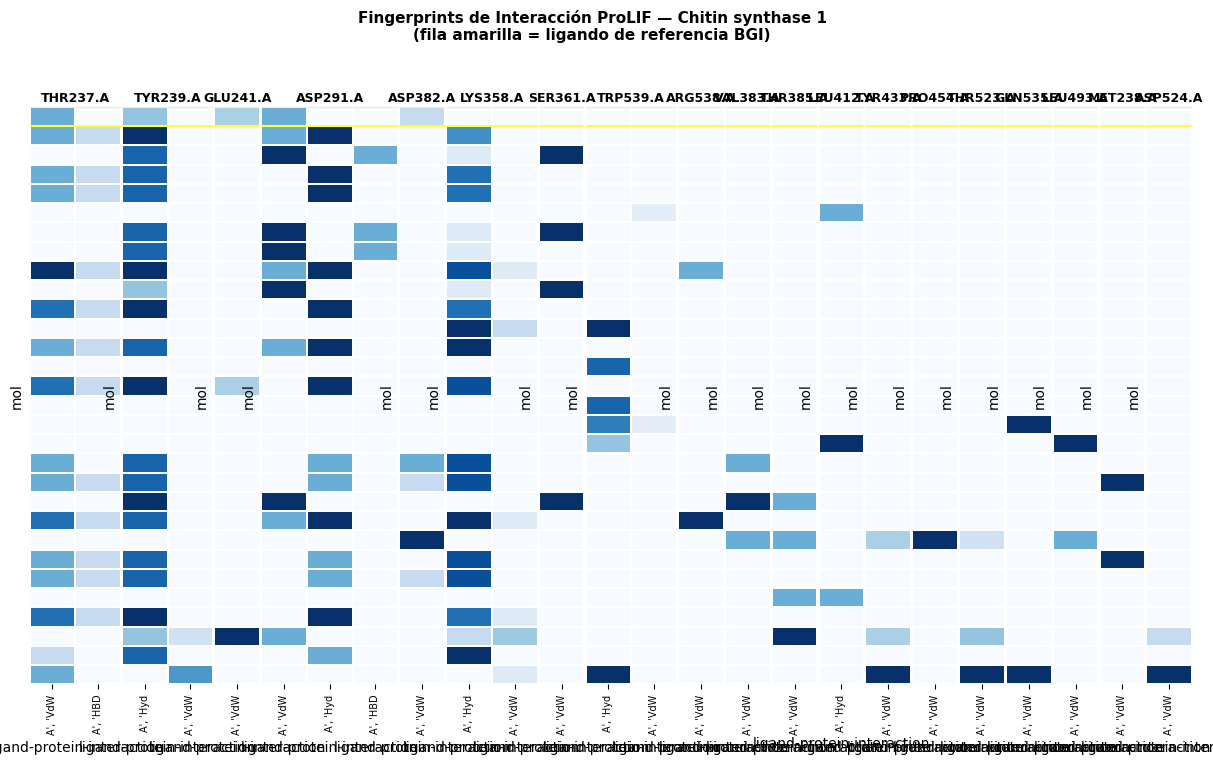

✅ Heatmap guardado: docking/heatmap_interacciones.png


In [30]:
# ── Heatmap por tipo de interacción ─────────────────────────────────────────
# Colores por tipo — consistente con la paleta del curso
c_maps = {
    'HBDonor':     'Blues',
    'HBAcceptor':  'Oranges',
    'Hydrophobic': 'Greens',
    'VdWContact':  'Greys',
    'PiStacking':  'Reds',
    'PiCation':    'Purples',
    'Cationic':    'YlOrRd',
    'Anionic':     'YlGnBu',
}

interaction_types = [t for t in grouped_columns if grouped_columns[t]]
col_widths = [len(grouped_columns[t]) for t in interaction_types]

if not interaction_types:
    print("⚠️  No hay suficientes interacciones para el heatmap")
else:
    fig, axes = plt.subplots(
        1, len(interaction_types),
        figsize=(max(12, sum(col_widths) * 0.6), max(6, len(fps_df) * 0.25)),
        sharey=True,
        gridspec_kw={'width_ratios': col_widths}
    )
    if len(interaction_types) == 1:
        axes = [axes]

    fig.subplots_adjust(wspace=0.02)

    for ax, tipo in zip(axes, interaction_types):
        cols_tipo = grouped_columns[tipo]
        data_tipo = fps_df[cols_tipo]

        # Nombres de columnas más legibles
        col_labels = [str(c).split('.')[-1][:8] if '.' in str(c) else str(c)[:8]
                      for c in cols_tipo]

        cmap = c_maps.get(tipo, 'Blues')
        sns.heatmap(
            data_tipo,
            ax=ax,
            cmap=cmap,
            cbar=False,
            xticklabels=col_labels,
            yticklabels=(ax == axes[0]),
            linewidths=0.2,
            linecolor='white'
        )
        ax.set_title(tipo, fontsize=9, fontweight='bold', pad=4)
        ax.tick_params(axis='x', labelsize=7, rotation=90)
        ax.tick_params(axis='y', labelsize=7)

    # Resaltar el ligando de referencia
    if LIGAND_CODE in fps_df.index:
        ref_idx = list(fps_df.index).index(LIGAND_CODE)
        for ax in axes:
            ax.axhline(ref_idx, color='yellow', linewidth=1.5, alpha=0.8)
            ax.axhline(ref_idx + 1, color='yellow', linewidth=1.5, alpha=0.8)

    fig.suptitle(
        f'Fingerprints de Interacción ProLIF — {TARGET_NAME}\n'
        f'(fila amarilla = ligando de referencia {LIGAND_CODE})',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.savefig(f'{docks_directory}/heatmap_interacciones.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Heatmap guardado: {docks_directory}/heatmap_interacciones.png")


---
## 9. Scoring compuesto: Vina + similitud ProLIF

### ¿Por qué combinar dos scores?

| Score solo | Limitación |
|-----------|-----------|
| Vina (energía) | Dos moléculas con el mismo score pueden unirse de forma completamente diferente |
| ProLIF (similitud) | Una molécula puede tener interacciones similares pero en una posición desfavorable energéticamente |
| **Combinado** | Selecciona moléculas que son **energéticamente favorables** Y **farmacológicamente específicas** |

### Fórmula del scoring compuesto

$$\text{Score final} = \frac{S_{\text{Vina}}^{\text{norm}} + S_{\text{ProLIF}}^{\text{coseno}}}{2}$$

Donde:
- $S_{\text{Vina}}^{\text{norm}}$: score de Vina invertido y normalizado a [0,1] con MinMaxScaler
  (el más negativo → 1.0; el menos negativo → 0.0)
- $S_{\text{ProLIF}}^{\text{coseno}}$: similitud coseno entre el fingerprint ProLIF de la molécula
  y el del ligando de referencia (cristal)


In [31]:
# ── Paso 1: Calcular la similitud coseno de ProLIF vs cristal ─────────────────
if LIGAND_CODE not in fps_df.index:
    print(f"⚠️  '{LIGAND_CODE}' no está en el índice de fps_df")
    print(f"   Índices disponibles: {fps_df.index[:5].tolist()}")
    referencia_fp = fps_df.iloc[0]
    print(f"   Usando '{fps_df.index[0]}' como referencia")
else:
    referencia_fp = fps_df.loc[LIGAND_CODE]

# Escalar los fingerprints a [0,1]
scaler = MinMaxScaler()
fps_scaled_arr = scaler.fit_transform(fps_df.values.astype(float))
fps_scaled = pd.DataFrame(fps_scaled_arr,
                           index=fps_df.index,
                           columns=fps_df.columns)

ref_vector = fps_scaled.loc[referencia_fp.name] if hasattr(referencia_fp, 'name') else fps_scaled.iloc[0]

def similitud_coseno(row):
    """Calcula 1 - distancia coseno (similitud) entre una fila y el vector de referencia."""
    return 1 - distance.cosine(ref_vector.values, row.values)

fps_scaled['cos_sim'] = fps_scaled.apply(similitud_coseno, axis=1)

print("SIMILITUD COSENO (ProLIF) vs CRISTAL")
print("=" * 45)
print(f"  Referencia: {ref_vector.name if hasattr(ref_vector,'name') else LIGAND_CODE}")
print(f"  Similitud media: {fps_scaled['cos_sim'].mean():.3f}")
print(f"  Rango: [{fps_scaled['cos_sim'].min():.3f}, {fps_scaled['cos_sim'].max():.3f}]")
print()
print(f"  Top 5 por similitud ProLIF:")
top_prolif = fps_scaled['cos_sim'].sort_values(ascending=False).head(6)
for mol, sim in top_prolif.items():
    flag = '★ REFERENCIA' if mol == LIGAND_CODE else ''
    print(f"  {mol:<25}: {sim:.4f}  {flag}")


SIMILITUD COSENO (ProLIF) vs CRISTAL
  Referencia: BGI
  Similitud media: 0.331
  Rango: [0.000, 1.000]

  Top 5 por similitud ProLIF:
  BGI                      : 1.0000  ★ REFERENCIA
  CHEMBL36240              : 0.5511  
  CHEMBL35735              : 0.5432  
  CHEMBL36409              : 0.4997  
  CHEMBL265094             : 0.4908  
  CHEMBL35760              : 0.4901  


In [32]:
# ── Paso 2: Normalizar el score de Vina ─────────────────────────────────────
# El score de Vina es negativo — el más negativo es el mejor
# Invertimos y normalizamos para que mayor = mejor

df_scoring = df_resultados[['molecule_chembl_id', 'std_smiles',
                              'pActividad', 'standard_type', 'vina_score']].copy()

vina_vals = df_scoring['vina_score'].values.reshape(-1, 1)

# Inversión: multiplicamos por -1 (el más negativo se vuelve el más positivo)
vina_inv = -vina_vals
scaler_vina = MinMaxScaler()
df_scoring['vina_norm'] = scaler_vina.fit_transform(vina_inv).flatten()

print("SCORE DE VINA NORMALIZADO")
print("=" * 45)
print(f"  Score Vina original — rango: [{df_scoring['vina_score'].min():.2f}, {df_scoring['vina_score'].max():.2f}] kcal/mol")
print(f"  Vina normalizado    — rango: [{df_scoring['vina_norm'].min():.3f}, {df_scoring['vina_norm'].max():.3f}]")
print(f"  (1.0 = mejor score de Vina, 0.0 = peor)")


SCORE DE VINA NORMALIZADO
  Score Vina original — rango: [-8.12, -6.40] kcal/mol
  Vina normalizado    — rango: [0.000, 1.000]
  (1.0 = mejor score de Vina, 0.0 = peor)


In [33]:
# ── Paso 3: Combinar en el scoring compuesto ─────────────────────────────────
# Añadir similitud ProLIF al DataFrame de scoring

# Alinear índices
fps_cos_dict = fps_scaled['cos_sim'].to_dict()
df_scoring['prolif_sim'] = df_scoring['molecule_chembl_id'].map(fps_cos_dict)
df_scoring['prolif_sim'] = df_scoring['prolif_sim'].fillna(0.0)

# Calcular el score compuesto
df_scoring['score_final'] = (df_scoring['vina_norm'] + df_scoring['prolif_sim']) / 2

# Ordenar por score final (mayor = mejor)
df_scoring = df_scoring.sort_values('score_final', ascending=False).reset_index(drop=True)
df_scoring.index = range(1, len(df_scoring) + 1)
df_scoring.index.name = 'Ranking'

print("RANKING FINAL — SCORING COMPUESTO")
print(f"Target: {TARGET_NAME}")
print("=" * 80)
print(f"{'#':>4}  {'ChEMBL ID':<18}  {'Vina (kcal/mol)':>15}  {'Vina norm':>9}  {'ProLIF sim':>10}  {'Score final':>11}")
print("-" * 80)
for rank, row in df_scoring.head(15).iterrows():
    print(f"  {rank:>2}.  {row['molecule_chembl_id']:<18}  "
          f"{row['vina_score']:>14.2f}  {row['vina_norm']:>9.4f}  "
          f"{row['prolif_sim']:>10.4f}  {row['score_final']:>11.4f}")


RANKING FINAL — SCORING COMPUESTO
Target: Chitin synthase 1
   #  ChEMBL ID           Vina (kcal/mol)  Vina norm  ProLIF sim  Score final
--------------------------------------------------------------------------------
   1.  CHEMBL285445                 -7.87     0.8515      0.4782       0.6648
   2.  CHEMBL35306                  -7.93     0.8875      0.4114       0.6494
   3.  CHEMBL36446                  -7.51     0.6450      0.4697       0.5574
   4.  CHEMBL32780                  -7.49     0.6340      0.4606       0.5473
   5.  CHEMBL36409                  -7.42     0.5934      0.4997       0.5466
   6.  CHEMBL36240                  -7.31     0.5290      0.5511       0.5401
   7.  CHEMBL35735                  -7.29     0.5168      0.5432       0.5300
   8.  CHEMBL285056                 -7.40     0.5771      0.4697       0.5234
   9.  CHEMBL443517                 -8.12     1.0000      0.0000       0.5000
  10.  CHEMBL35516                  -7.49     0.6305      0.3478       0.4891
 

---
## 10. Análisis de resultados y selección de candidatos


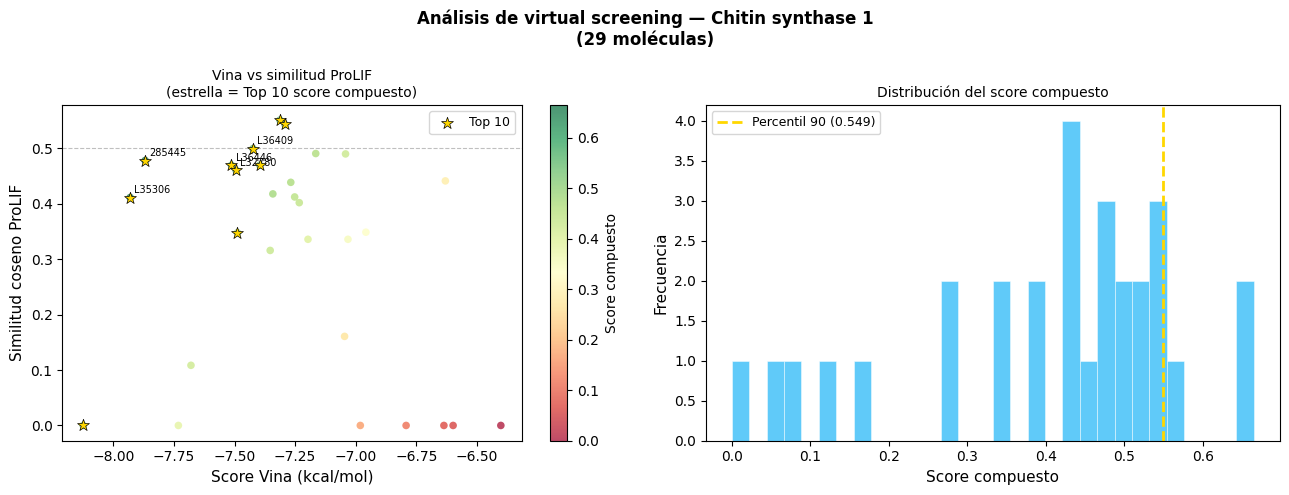

In [34]:
# ── Scatter plot: Vina score vs similitud ProLIF ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: scatter Vina vs ProLIF
ax1 = axes[0]
sc = ax1.scatter(
    df_scoring['vina_score'],
    df_scoring['prolif_sim'],
    c=df_scoring['score_final'],
    cmap='RdYlGn', s=30, alpha=0.7, edgecolors='none'
)
plt.colorbar(sc, ax=ax1, label='Score compuesto')

# Marcar el top 10
top10 = df_scoring.head(10)
ax1.scatter(top10['vina_score'], top10['prolif_sim'],
            s=80, marker='*', c='gold', edgecolors='black',
            linewidth=0.5, zorder=5, label='Top 10')
for _, row in top10.head(5).iterrows():
    ax1.annotate(row['molecule_chembl_id'][-6:],
                 (row['vina_score'], row['prolif_sim']),
                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax1.set_xlabel('Score Vina (kcal/mol)', fontsize=11)
ax1.set_ylabel('Similitud coseno ProLIF', fontsize=11)
ax1.set_title('Vina vs similitud ProLIF\n(estrella = Top 10 score compuesto)', fontsize=10)
ax1.legend(fontsize=9)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Panel derecho: distribución del score compuesto
ax2 = axes[1]
ax2.hist(df_scoring['score_final'], bins=30,
         color='#38bdf8', alpha=0.8, edgecolor='white', linewidth=0.4)
ax2.axvline(df_scoring['score_final'].quantile(0.9),
            color='gold', linestyle='--', linewidth=2,
            label=f'Percentil 90 ({df_scoring["score_final"].quantile(0.9):.3f})')
ax2.set_xlabel('Score compuesto', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución del score compuesto', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle(f'Análisis de virtual screening — {TARGET_NAME}\n'
             f'({len(df_scoring)} moléculas)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{docks_directory}/analisis_scoring.png', dpi=130, bbox_inches='tight')
plt.show()


In [35]:
# ── Comparar ranking por Vina solo vs score compuesto ───────────────────────
# Esto ilustra por qué el scoring compuesto cambia la selección

ranking_vina = df_scoring.sort_values('vina_score').reset_index()['molecule_chembl_id'].head(10).tolist()
ranking_comp = df_scoring.sort_values('score_final', ascending=False).reset_index()['molecule_chembl_id'].head(10).tolist()

print("COMPARACIÓN: Top 10 por Vina solo vs Score Compuesto")
print("=" * 60)
print(f"{'Pos':>3}  {'Por Vina (kcal/mol)':^25}  {'Por Score Compuesto':^25}")
print("-" * 60)
for i, (v, c) in enumerate(zip(ranking_vina, ranking_comp), 1):
    mismo = '← igual' if v == c else ''
    print(f"  {i:>2}.  {v:<25}  {c:<25} {mismo}")

moléculas_nuevas = len(set(ranking_comp) - set(ranking_vina))
print()
print(f"Moléculas en el top 10 del score compuesto")
print(f"que NO estaban en el top 10 de Vina solo: {moléculas_nuevas}")
print()
print("💡 Si este número es > 0, el scoring compuesto está añadiendo")
print("   información real sobre la especificidad de interacciones.")


COMPARACIÓN: Top 10 por Vina solo vs Score Compuesto
Pos     Por Vina (kcal/mol)        Por Score Compuesto   
------------------------------------------------------------
   1.  CHEMBL443517               CHEMBL285445              
   2.  CHEMBL35306                CHEMBL35306               ← igual
   3.  CHEMBL285445               CHEMBL36446               
   4.  CHEMBL287110               CHEMBL32780               
   5.  CHEMBL1791436              CHEMBL36409               
   6.  CHEMBL36446                CHEMBL36240               
   7.  CHEMBL32780                CHEMBL35735               
   8.  CHEMBL35516                CHEMBL285056              
   9.  CHEMBL36409                CHEMBL443517              
  10.  CHEMBL285056               CHEMBL35516               

Moléculas en el top 10 del score compuesto
que NO estaban en el top 10 de Vina solo: 2

💡 Si este número es > 0, el scoring compuesto está añadiendo
   información real sobre la especificidad de interacciones.


In [36]:
# ── Top candidatos: interacciones con el sitio de unión ─────────────────────
# Analizar qué residuos contacta el mejor candidato vs el cristal

print("ANÁLISIS DE INTERACCIONES — Top 3 candidatos vs cristal")
print("=" * 60)

top3 = df_scoring.head(3)['molecule_chembl_id'].tolist()
mols_analisis = [LIGAND_CODE] + top3 if LIGAND_CODE in fps_df.index else top3

for mol_id in mols_analisis:
    if mol_id not in fps_df.index:
        continue
    fp_mol = fps_df.loc[mol_id]
    interacciones = fp_mol[fp_mol > 0]
    n_int = len(interacciones)
    tag = '★ CRISTAL' if mol_id == LIGAND_CODE else f'rank #{df_scoring[df_scoring.molecule_chembl_id==mol_id].index[0] if mol_id in df_scoring.molecule_chembl_id.values else "?"}'
    print(f"\n  {mol_id} ({tag})")
    print(f"  Interacciones activas: {n_int}")
    for col, val in interacciones.items():
        col_str = str(col)
        print(f"    {col_str[:50]}: {val}")


ANÁLISIS DE INTERACCIONES — Top 3 candidatos vs cristal

  BGI (★ CRISTAL)
  Interacciones activas: 5
    ('UNL1', 'THR237.A', 'VdWContact'): 2
    ('UNL1', 'TYR239.A', 'Hydrophobic'): 2
    ('UNL1', 'GLU241.A', 'VdWContact'): 1
    ('UNL1', 'ASP291.A', 'VdWContact'): 1
    ('UNL1', 'ASP382.A', 'VdWContact'): 1

  CHEMBL285445 (rank #1)
  Interacciones activas: 5
    ('UNL1', 'TYR239.A', 'Hydrophobic'): 5
    ('UNL1', 'ASP291.A', 'VdWContact'): 2
    ('UNL1', 'SER361.A', 'VdWContact'): 1
    ('UNL1', 'VAL383.A', 'VdWContact'): 2
    ('UNL1', 'THR385.A', 'VdWContact'): 1

  CHEMBL35306 (rank #2)
  Interacciones activas: 10
    ('UNL1', 'TYR239.A', 'Hydrophobic'): 2
    ('UNL1', 'GLU241.A', 'VdWContact'): 3
    ('UNL1', 'ASP291.A', 'VdWContact'): 1
    ('UNL1', 'LYS358.A', 'Hydrophobic'): 2
    ('UNL1', 'LYS358.A', 'VdWContact'): 3
    ('UNL1', 'THR385.A', 'VdWContact'): 2
    ('UNL1', 'TYR433.A', 'VdWContact'): 1
    ('UNL1', 'THR523.A', 'VdWContact'): 2
    ('UNL1', 'TYR239.A', 'VdWCon

---
## 11. Guardar los resultados finales


In [37]:
# ── Preparar y guardar la tabla de resultados completa ──────────────────────
TARGET_SLUG = TARGET_NAME.lower().replace(' ', '_').replace('/', '_')[:30]

# Tabla completa sin la columna PDBQT (ocupa mucho espacio)
df_final = df_scoring.copy()
df_final = df_final.drop(columns=['pdbqt'], errors='ignore')

archivo_ranking = f'{docks_directory}/ranking_final_{TARGET_SLUG}.csv'
df_final.to_csv(archivo_ranking, index=True)

print("✅ ARCHIVOS GUARDADOS")
print("=" * 55)
for archivo in [
    archivo_ranking,
    f'{docks_directory}/fps_activos.csv',
    f'{docks_directory}/heatmap_interacciones.png',
    f'{docks_directory}/analisis_scoring.png'
]:
    if os.path.exists(archivo):
        tam = os.path.getsize(archivo) / 1024
        print(f"  {archivo:<50} ({tam:.0f} KB)")

print()
print("RESUMEN FINAL DEL VIRTUAL SCREENING")
print("=" * 55)
print(f"  Target:                  {TARGET_NAME}")
print(f"  Moléculas cribadas:      {len(df_scoring)}")
print(f"  Score Vina medio:        {df_scoring['vina_score'].mean():.2f} kcal/mol")
print(f"  Similitud ProLIF media:  {df_scoring['prolif_sim'].mean():.3f}")
print(f"  Score compuesto medio:   {df_scoring['score_final'].mean():.3f}")
print()
print("  TOP 5 CANDIDATOS (score compuesto):")
for rank, row in df_final.head(5).iterrows():
    print(f"  {rank:>2}. {row['molecule_chembl_id']:<20} "
          f"Vina={row['vina_score']:.2f}  ProLIF={row['prolif_sim']:.3f}  "
          f"Final={row['score_final']:.3f}")


✅ ARCHIVOS GUARDADOS
  docking/ranking_final_chitin_synthase_1.csv        (4 KB)
  docking/fps_activos.csv                            (2 KB)
  docking/heatmap_interacciones.png                  (69 KB)
  docking/analisis_scoring.png                       (91 KB)

RESUMEN FINAL DEL VIRTUAL SCREENING
  Target:                  Chitin synthase 1
  Moléculas cribadas:      29
  Score Vina medio:        -7.25 kcal/mol
  Similitud ProLIF media:  0.308
  Score compuesto medio:   0.400

  TOP 5 CANDIDATOS (score compuesto):
   1. CHEMBL285445         Vina=-7.87  ProLIF=0.478  Final=0.665
   2. CHEMBL35306          Vina=-7.93  ProLIF=0.411  Final=0.649
   3. CHEMBL36446          Vina=-7.51  ProLIF=0.470  Final=0.557
   4. CHEMBL32780          Vina=-7.49  ProLIF=0.461  Final=0.547
   5. CHEMBL36409          Vina=-7.42  ProLIF=0.500  Final=0.547


---
## ✅ Resumen del notebook

| Paso | Función / herramienta | Resultado |
|------|----------------------|-----------|
| **Descarga ChEMBL** | `chembl_mols()` | Moléculas activas con filtros QSAR |
| **Curación** | `process_smiles()` | SMILES limpios, sin sales, canónicos |
| **Conformeros** | `get_conformers()` (ETKDGv3 + UFF) | PDB del mínimo energético por molécula |
| **PDBQT ligandos** | `prepare_ligands()` (Meeko) | Cargas Gasteiger + torsiones |
| **Docking batch** | `vina_docking()` | 5 poses × n moléculas → SDF |
| **Fingerprints** | `get_prolif()` (ProLIF) | Matriz residuo × tipo de interacción |
| **Heatmap** | seaborn | Visualización agrupada por tipo de interacción |
| **Score Vina norm.** | MinMaxScaler | Energía invertida y escalada a [0,1] |
| **Similitud ProLIF** | Similitud coseno | ¿Cómo de similar al ligando de referencia? |
| **Score compuesto** | (Vina + ProLIF) / 2 | Ranking integrado |

## ✅ Conexión con los demás notebooks del curso

```
NB-DATA-01/02  →  dataset curado de ChEMBL   ─┐
NB-DATA-03     →  espacio químico explorado    ├─→ NB-DOCK-02 (este notebook)
NB-ML-01       →  modelos QSAR activo/inactivo ─┘        ↓
NB-DOCK-01     →  protocolo validado (RMSD≤2Å)    Ranking de candidatos
```

Los candidatos del Top 10 pueden ahora:
1. Priorizarse para síntesis o compra
2. Cruzarse con los activos del modelo QSAR (NB-ML-01)
3. Visualizarse en 3D con NGLview para inspección manual

---
*NB-DOCK-02 · Ciencia de Datos en Descubrimiento de Fármacos · UNAL 2026*  
*Pipeline basado en: ChEMBL, RDKit, Meeko, AutoDock Vina, ProLIF*
